### **IMPORTO LIBRERIE**

In [37]:
import pandas as pd

### **IMPORTO DATI**

In [38]:
#Importo i dataframe precedentemente puliti per l'analisi
df_software_outlier_medi = pd.read_csv("datas/processed/dataset_software_outlier_medi.csv")
df_hardware_outlier_medi = pd.read_csv("datas/processed/dataset_hardware_outlier_medi.csv")
df_software_outlier_singoli = pd.read_csv("datas/processed/dataset_software_outlier_singoli.csv")
df_hardware_outlier_singoli = pd.read_csv("datas/processed/dataset_hardware_outlier_singoli.csv")
df_software_outlier_medi_winsorizzati = pd.read_csv("datas/processed/dataset_software_outlier_medi_winsorizzati.csv")
df_hardware_outlier_medi_winsorizzati = pd.read_csv("datas/processed/dataset_hardware_outlier_medi_winsorizzati.csv")

### **STATISTICA DESCRITTIVA**

In [39]:
colonne_descrittive = [
    "roe_medio",
    "debt_equity_medio",
    "liquidita_media",
    "log_attivo_medio",
]

# Preparo la tabella con le statistiche descrittive per le colonne selezionate
statistica_descrittiva_outlier_singoli = df_software_outlier_singoli[colonne_descrittive].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

statistica_descrittiva_outlier_medi = df_software_outlier_medi[colonne_descrittive].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

statistica_descrittiva_outlier_medi_winsorizzati = df_software_outlier_medi_winsorizzati[colonne_descrittive].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

In [40]:
print("Dimensione campione totale: " + str(len(df_software_outlier_medi) + len(df_hardware_outlier_medi)) + " osservazioni.")
statistica_descrittiva_outlier_medi

Dimensione campione totale: 372 osservazioni.


,roe_medio,debt_equity_medio,liquidita_media,log_attivo_medio
mean,-14.379442,1.196881,2.502835,13.403949
median,-6.102533,0.953112,2.016333,13.664256
std,31.168842,0.941461,1.505446,2.192224
min,-112.111200,0.043108,0.272200,7.104794
max,55.448000,4.313645,7.065600,19.751048


In [41]:
print("Dimensione campione totale: " + str(len(df_software_outlier_singoli) + len(df_hardware_outlier_singoli)) + " osservazioni.")
statistica_descrittiva_outlier_singoli

Dimensione campione totale: 256 osservazioni.


,roe_medio,debt_equity_medio,liquidita_media,log_attivo_medio
mean,-3.420946,0.959806,2.360750,13.808983
median,-2.284800,0.781442,2.065200,13.963904
std,18.619728,0.632945,1.208537,2.120889
min,-62.594333,0.043108,0.416000,7.104794
max,38.434800,2.842697,5.767600,19.751048


In [42]:
print("Dimensione campione totale: " + str(len(df_software_outlier_medi_winsorizzati) + len(df_hardware_outlier_medi_winsorizzati)) + " osservazioni.")
statistica_descrittiva_outlier_medi_winsorizzati

Dimensione campione totale: 479 osservazioni.


,roe_medio,debt_equity_medio,liquidita_media,log_attivo_medio
mean,-26.426197,1.555037,3.180958,13.124715
median,-11.070800,0.988216,2.112400,13.477264
std,46.523772,1.638611,2.782274,2.349922
min,-147.897200,0.158397,0.808500,7.104794
max,25.121600,6.324068,11.398800,19.751048


Dato che il ROE medio e mediano è negativo, penso sia interessante analizzare il modo in cui è distribuito (prevedendo ovviamente un'asimmetria a sinistra).

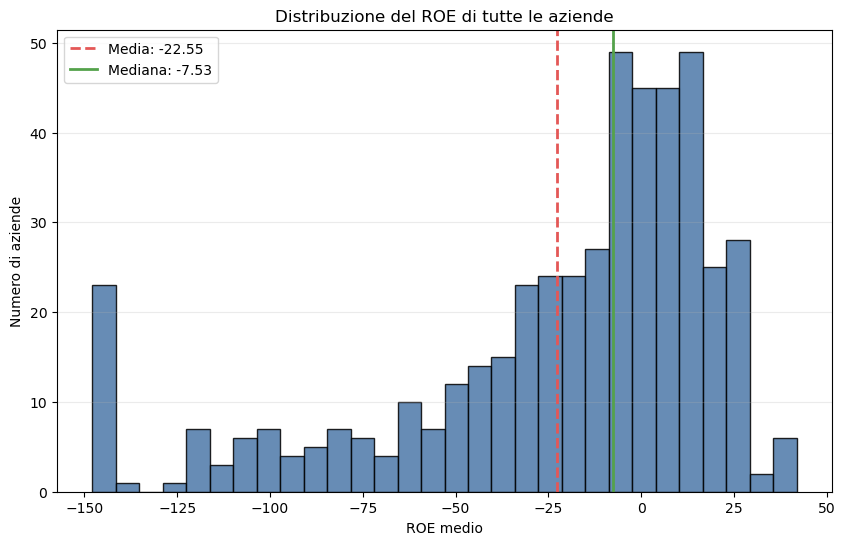

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Distribuzione del ROE di tutte le aziende'}, xlabel='ROE medio', ylabel='Numero di aziende'>)

In [ ]:
def mostra_istogramma_roe(df, nome_database, colonna_roe="roe_medio", bins=30):
    import matplotlib.pyplot as plt

    roe = df[colonna_roe].dropna()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(roe, bins=bins, color="#4C78A8", edgecolor="black", alpha=0.85)
    ax.axvline(roe.mean(), color="#E45756", linestyle="--", linewidth=2, label=f"Media: {roe.mean():.2f}")
    ax.axvline(roe.median(), color="#54A24B", linestyle="-", linewidth=2, label=f"Mediana: {roe.median():.2f}")
    ax.set_title(f"Distribuzione del ROE - {nome_database}")
    ax.set_xlabel("ROE medio")
    ax.set_ylabel("Numero di aziende")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.show()

    return fig, ax


mostra_istogramma_roe(
    df_software_outlier_medi_winsorizzati,
    "Software winsorizzato"
);

mostra_istogramma_roe(
    df_hardware_outlier_medi_winsorizzati,
    "Hardware winsorizzato"
);